In [ ]:
import sys
sys.path.append(r'C:\Users\ozsha\prot_cv\ML')


from common import (
    _PROJECT_ROOT, log, 
    RESULTS_DIR, FIGURES_DIR, DEFAULT_TARGET,
    PREDICTION_ERROR_THRESHOLDS, DDG_THRESHOLDS,
    ERROR_LABELS, CLASS_LABELS,
    load_results, prepare_xy, build_pdb_paths,
    lopo_cv, per_structure_cv,
    get_feature_importances, plot_importances, plot_per_structure_results,
    binarize_target,
)

from sklearn.ensemble import RandomForestClassifier , HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (balanced_accuracy_score, classification_report,
                              confusion_matrix)


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import logging



In [3]:
%matplotlib inline

In [ ]:

dff = pd.read_parquet("./results/feature_matrix_extended_DDG.parquet")
print (dff.shape)
dff['mut_to'] = dff['mut_aa']
dff = dff.loc[dff[['pdb_id','chain','resnum', 'mut_to']].drop_duplicates().index].reset_index(drop=True)
dff = dff[dff.groupby(['pdb_id','chain','resnum'])['mut_to'].transform('count') > 1].reset_index(drop=True)
print (f"After dropping duplicates: {dff.shape}")
#DDG_THRESHOLDS              = (-0.2, 0.75) 

args = lambda: None
args.target = "DDG"
#args.target = "prediction_error"
args.include_foldx = False
args.extended_features = False

pdb_paths = build_pdb_paths(dff)

X, y, groups, feature_names, df_valid = prepare_xy(
    dff, target=args.target,
    include_foldx=args.include_foldx,
    pdb_paths=pdb_paths or None
)

# Save feature matrix with merge keys (used by assemble_features.py)
feature_df = X.copy()
feature_df[args.target] = y.values
feature_df["pdb_id"]    = groups.values
for col in ["chain", "resnum", "wt_aa", "mut_aa"]:
    if col in df_valid.columns:
        feature_df[col] = df_valid[col].values
out_parquet = RESULTS_DIR / f"feature_matrix_{args.target}.parquet"
feature_df.to_parquet(out_parquet, index=False)
log.info("Feature matrix saved: %s (%d rows x %d features)",
            out_parquet, len(feature_df), len(feature_names))

# Binarize target
thresholds = PREDICTION_ERROR_THRESHOLDS if args.target == "prediction_error" else DDG_THRESHOLDS
labels     = ERROR_LABELS if args.target == "prediction_error" else CLASS_LABELS
y_cls      = binarize_target(y, thresholds=thresholds, labels=labels)

valid  = y_cls.notna()
X_c    = X[valid]
y_c    = y_cls[valid]
g_c    = groups[valid]
pos_c  = df_valid.loc[X_c.index, "resnum"] if "resnum" in df_valid.columns else None




INFO | PDB files found: ['1A22', '1A4Y', '1AO7', '1B41', '1BP3', '1BRS', '1CBW', '1CHO', '1DAN', '1FC2', '1FSS', '1IAR', '1JRH', '1JTG', '1KTZ', '1LFD', '1MHP', '1OGA', '1PPF', '1R0R', '1TM1', '1VFB', '2FTL', '2G2U', '2JEL', '2NYY', '2WPT', '3BN9', '3HFM', '3NGB', '3QDG', '3S9D', '3SE4', '3SGB', '4BFI', '4G0N', '4I77', '4RS1']


(3015, 86)
After dropping duplicates: (1263, 87)


INFO | Computing protein features for 1A22
INFO | Computing protein features for 1A4Y
INFO | Computing protein features for 1AO7
INFO | Computing protein features for 1B41
INFO | Computing protein features for 1BP3
INFO | Computing protein features for 1BRS
INFO | Computing protein features for 1CBW
INFO | Computing protein features for 1CHO
INFO | Computing protein features for 1DAN
INFO | Computing protein features for 1FC2
INFO | Computing protein features for 1FSS
INFO | Computing protein features for 1IAR
INFO | Computing protein features for 1JRH
INFO | Computing protein features for 1JTG
INFO | Computing protein features for 1KTZ
INFO | Computing protein features for 1LFD
INFO | Computing protein features for 1MHP
INFO | Computing protein features for 1OGA
INFO | Computing protein features for 1PPF
INFO | Computing protein features for 1R0R
INFO | Computing protein features for 1TM1
INFO | Computing protein features for 1VFB
INFO | Computing protein features for 2FTL
INFO | Comp

In [5]:
def build_features(dff, X_c, include_foldx=True):
    """Combine base features with optional FoldX ddg column."""
    print (f"Columns with missing values (median impute): {X_c.columns[X_c.isnull().mean()>0].tolist()}")
    X_c = X_c.fillna(X_c.median())
    if include_foldx:
        return pd.concat([X_c, dff['ddg_foldx_calibrated']], axis=1)
    return X_c.copy()


# ── 2. Label builder ──────────────────────────────────────────────────────────

def build_labels(y, threshold=-0.25):
    """Binary classification: destabilizing = 1."""
    return (y < threshold).astype(int)



In [6]:
# ── configure once ────────────────────────────────────────────────────────────
XX   = build_features(dff, X_c, include_foldx=True)
yy   = build_labels(y, threshold=-0.05)
g   = g_c  # your group series

Columns with missing values (median impute): []


In [7]:
# ── Setup ─────────────────────────────────────────────────────────────────────

logging.basicConfig(level=logging.INFO)

from protein_cv import (
    run_cv_structures, run_cv_positions, summarize_cv,
    run_loo_retraining, filter_multi_mutation_positions,
    summarize_loo_logloss,   # Table 1: Wilcoxon on logloss delta
    summarize_loo_correct,   # Table 2: Wilcoxon on flip rate
    plot_loo_heatmaps,       # 2x2 grid: both tables x M1/M2
)

In [8]:
def logloss(raw_no_sib):
    y = raw_no_sib['y_true']
    p = raw_no_sib['y_proba']

    # clip p to avoid log(0) errors
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))

In [9]:
models_trees = {
    'RF_balanced':  RandomForestClassifier(class_weight='balanced',n_estimators=50, max_depth=2, 
                                           min_samples_leaf=15, random_state=42),
    'HGB_balanced': HistGradientBoostingClassifier(max_iter=50, max_depth=2,min_samples_leaf=15,
                        class_weight='balanced', random_state=42),
    'HGB_balanced': HistGradientBoostingClassifier(
    max_iter=50, max_depth=2, min_samples_leaf=15,
    class_weight='balanced', random_state=42,
    l2_regularization=1.0,    # ← add L2
    early_stopping=True,       # ← stop when test stops improving
    validation_fraction=0.15,
    n_iter_no_change=10,
)
}

### Predict stabilizing

In [10]:
selected_cols = [col for col in XX.columns if 'et' in col or 'foldx' in col ]

In [11]:
print (f"Cols in model : {selected_cols}")

Cols in model : ['et_total_energy', 'et_backbone_hbond', 'et_sidechain_hbond', 'et_vdw', 'et_electrostatics', 'et_solvation_polar', 'et_solvation_hydrophobic', 'et_vdw_clashes', 'et_entropy_sidechain', 'et_entropy_mainchain', 'et_sloop_entropy', 'et_mloop_entropy', 'et_cis_bond', 'et_torsional_clash', 'et_backbone_clash', 'et_helix_dipole', 'ddg_foldx_calibrated']


In [13]:
from sklearn.metrics import roc_auc_score
from protein_cv import run_cv_kfold, summarize_cv , add_sibling_features
from protein_cv import filter_multi_mutation_positions
# ── Train on >=2 mutations, reliable structures only ─────────────────────────
dff['resnum'] = dff['resnum'].astype(str) + '_' + dff['chain']  # Combine resnum and chain for sibling matching
pos_filter_2    = filter_multi_mutation_positions(g, dff['resnum'], min_mutations=2)
reliable_mask_2 = pos_filter_2 #& g.isin(structs_both_class)

XX_f2  = XX[reliable_mask_2]
dff_f2 = dff[reliable_mask_2]
g_f2   = g[reliable_mask_2]
yy_f2  = yy[reliable_mask_2]

print(f"Training set: {len(XX_f2)} mutations, {g_f2.nunique()} structures")
print(f"Class balance: {yy_f2.mean():.2f}")

X_trees_2 = add_sibling_features(XX_f2[selected_cols], dff_f2, g_f2,
                                   dff_f2['resnum'], dff_f2['mut_to'],
                                   ddg_col='DDG', mode='trees')
X_lr_2    = add_sibling_features(XX_f2[selected_cols], dff_f2, g_f2,
                                   dff_f2['resnum'], dff_f2['mut_to'],
                                   ddg_col='DDG', mode='lr')

# ── Evaluate only on >=3 positions ───────────────────────────────────────────
pos_filter_3 = filter_multi_mutation_positions(g_f2, dff_f2['resnum'], min_mutations=3)
eval_mask    = pd.Series(pos_filter_3.values, index=X_trees_2.index)

print(f"Evaluation set (>=3 muts/pos): {eval_mask.sum()} mutations")

raw_no_sib , df_imp_no_sib   = run_cv_kfold(X_trees_2[[c for c in X_trees_2.columns
                             if 'sibling_ddg' not in c]],
                             yy_f2, models_trees, groups=g_f2,
                             n_splits=4, raw=True , feature_importance=True,use_permutation=True)

raw_with_sib , df_imp_sib = run_cv_kfold(X_trees_2, yy_f2, models_trees,
                             groups=g_f2, n_splits=4, raw=True , feature_importance=True,use_permutation=True)

raw_no_sib_eval   = raw_no_sib[raw_no_sib['idx'].isin(X_trees_2[eval_mask].index)]
raw_with_sib_eval = raw_with_sib[raw_with_sib['idx'].isin(X_trees_2[eval_mask].index)]

raw_no_sib_eval['logloss'] = logloss(raw_no_sib_eval)
raw_with_sib_eval['logloss'] = logloss(raw_with_sib_eval)



INFO | Position filter (>=2 mutations): 82/82 positions kept, 895/1263 mutations kept
INFO | Sibling features (mode='trees'): 20 AA columns | coverage=78.8% | 895/895 mutations have ≥1 sibling
INFO | Sibling features (mode='lr'): 20 AA columns | coverage=100.0% | 895/895 mutations have ≥1 sibling
INFO | Position filter (>=3 mutations): 65/82 positions kept, 861/895 mutations kept


Training set: 895 mutations, 10 structures
Class balance: 0.21
Evaluation set (>=3 muts/pos): 861 mutations
Test set : Fold  0, model RF_balanced: AUC=0.872, BalAcc=0.764, LogLoss=0.546
Train set : Fold  0, model RF_balanced: AUC=0.851, BalAcc=0.768, LogLoss=0.548
Test set : Fold  0, model HGB_balanced: AUC=0.878, BalAcc=0.787, LogLoss=0.485
Train set : Fold  0, model HGB_balanced: AUC=0.876, BalAcc=0.793, LogLoss=0.474
Test set : Fold  1, model RF_balanced: AUC=0.842, BalAcc=0.743, LogLoss=0.516
Train set : Fold  1, model RF_balanced: AUC=0.858, BalAcc=0.779, LogLoss=0.540
Test set : Fold  1, model HGB_balanced: AUC=0.814, BalAcc=0.711, LogLoss=0.472
Train set : Fold  1, model HGB_balanced: AUC=0.906, BalAcc=0.839, LogLoss=0.430
Test set : Fold  2, model RF_balanced: AUC=0.792, BalAcc=0.703, LogLoss=0.566
Train set : Fold  2, model RF_balanced: AUC=0.888, BalAcc=0.819, LogLoss=0.514
Test set : Fold  2, model HGB_balanced: AUC=0.811, BalAcc=0.730, LogLoss=0.484
Train set : Fold  2, mod

In [14]:
print("\nNo siblings (evaluated on >=3 positions, reliable structures):")
for name, grp in raw_no_sib_eval.groupby('model'):
    print(f"  {name}: AUC={roc_auc_score(grp['y_true'], grp['y_proba']):.3f}")
    print(f"  {name}: Log Loss={grp['logloss'].mean():.3f}")

print("\nWith siblings (evaluated on >=3 positions, reliable structures):")
for name, grp in raw_with_sib_eval.groupby('model'):
    print(f"  {name}: AUC={roc_auc_score(grp['y_true'], grp['y_proba']):.3f}")
    print(f"  {name}: Log Loss={grp['logloss'].mean():.3f}")


No siblings (evaluated on >=3 positions, reliable structures):
  HGB_balanced: AUC=0.816
  HGB_balanced: Log Loss=0.499
  RF_balanced: AUC=0.809
  RF_balanced: Log Loss=0.554

With siblings (evaluated on >=3 positions, reliable structures):
  HGB_balanced: AUC=0.863
  HGB_balanced: Log Loss=0.432
  RF_balanced: AUC=0.855
  RF_balanced: Log Loss=0.473


In [15]:
df_sibs = pd.concat([raw_no_sib_eval, raw_with_sib_eval], keys=['no_sib', 'with_sib'], names=['siblings']).reset_index()

df_diff_sibs_effect = df_sibs.groupby(['model','structure','siblings'])['logloss'].mean().reset_index().pivot_table(index=['model','structure'], columns='siblings', values='logloss').diff(axis=1).reset_index()
print ("logloss difference between with and without siblings:\n" , df_diff_sibs_effect.groupby('model')['with_sib'].describe()[['mean','50%']])

print ("logloss difference between with and without siblings per structure:\n" , df_diff_sibs_effect[['model','structure','with_sib']])

logloss difference between with and without siblings:
                   mean       50%
model                           
HGB_balanced -0.032212 -0.055808
RF_balanced  -0.100856 -0.089615
logloss difference between with and without siblings per structure:
 siblings         model structure  with_sib
0         HGB_balanced      1B41 -0.065381
1         HGB_balanced      1BRS -0.032867
2         HGB_balanced      1CHO -0.041042
3         HGB_balanced      1FSS  0.038907
4         HGB_balanced      1PPF -0.134319
5         HGB_balanced      1R0R -0.055808
6         HGB_balanced      1VFB  0.121787
7         HGB_balanced      3HFM -0.057019
8         HGB_balanced      3SGB -0.064170
9          RF_balanced      1B41 -0.233090
10         RF_balanced      1BRS -0.034317
11         RF_balanced      1CHO -0.035618
12         RF_balanced      1FSS -0.167166
13         RF_balanced      1PPF -0.100323
14         RF_balanced      1R0R -0.081764
15         RF_balanced      1VFB -0.089615
16         RF

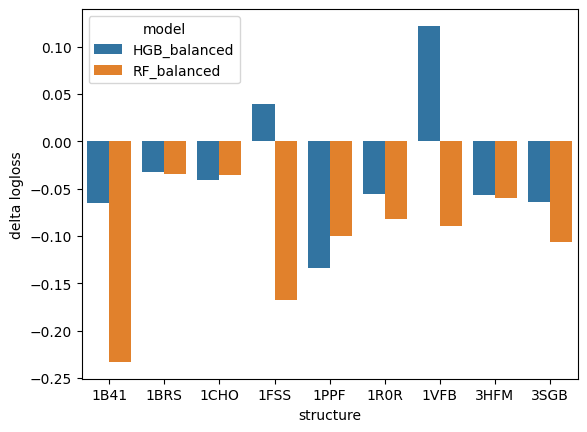

In [20]:
sns.barplot(data=df_diff_sibs_effect.rename(columns={'with_sib': 'delta logloss'}), x='structure', y='delta logloss', hue='model')
plt.savefig(FIGURES_DIR / f'logloss_delta_per_structure.png')

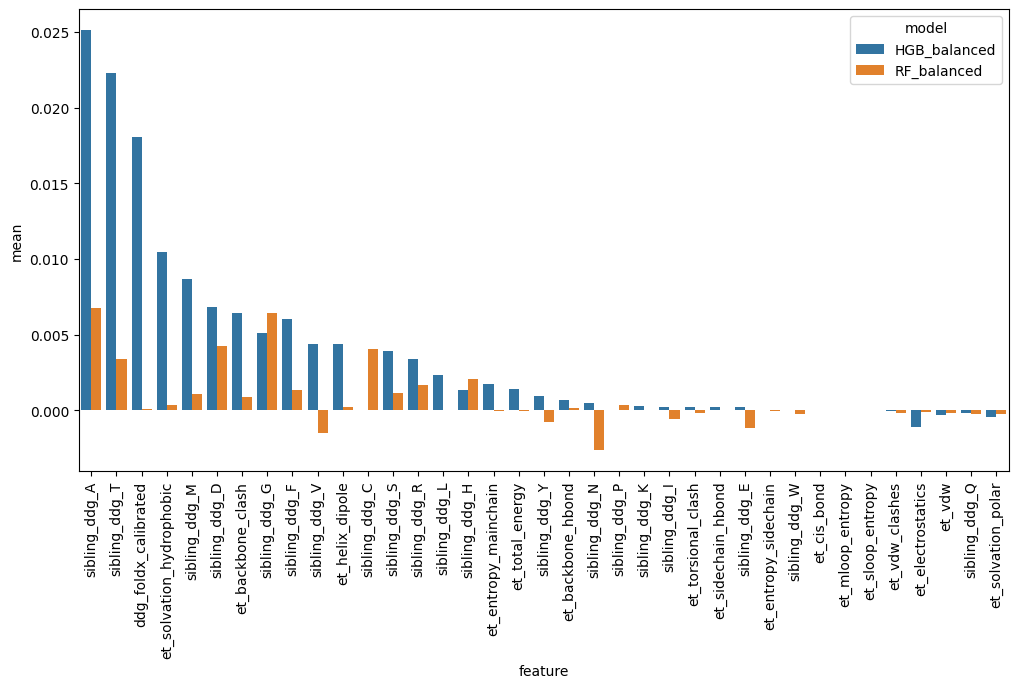

In [21]:

# Height 6, Aspect 2 results in a 12x6 figure
import matplotlib.pyplot as plt
import seaborn as sns

# Frequency-normalized importance
sibling_cols = [c for c in X_trees_2.columns if c.startswith('sibling_ddg_')]
coverage = X_trees_2[sibling_cols].notna().mean()  # fraction non-NaN per feature

imp_normalized = df_imp_sib.copy()
imp_normalized.loc[imp_normalized['feature'].isin(sibling_cols), 'mean'] /= \
    imp_normalized.loc[imp_normalized['feature'].isin(sibling_cols), 'feature'].map(coverage)

plt.figure(figsize=(12, 6))
sns.barplot(data=imp_normalized.sort_values('mean', ascending=False), x='feature', y='mean', hue='model')

# Rotate ticks 90 degrees
plt.xticks(rotation=90) 
plt.savefig(FIGURES_DIR / f'feature_importance_permutation.png')
plt.show()

<Axes: xlabel='mut_to'>

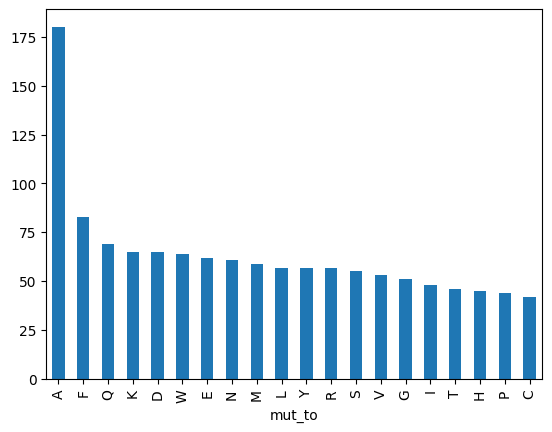

In [22]:
dff['mut_to'].value_counts().plot(kind='bar')

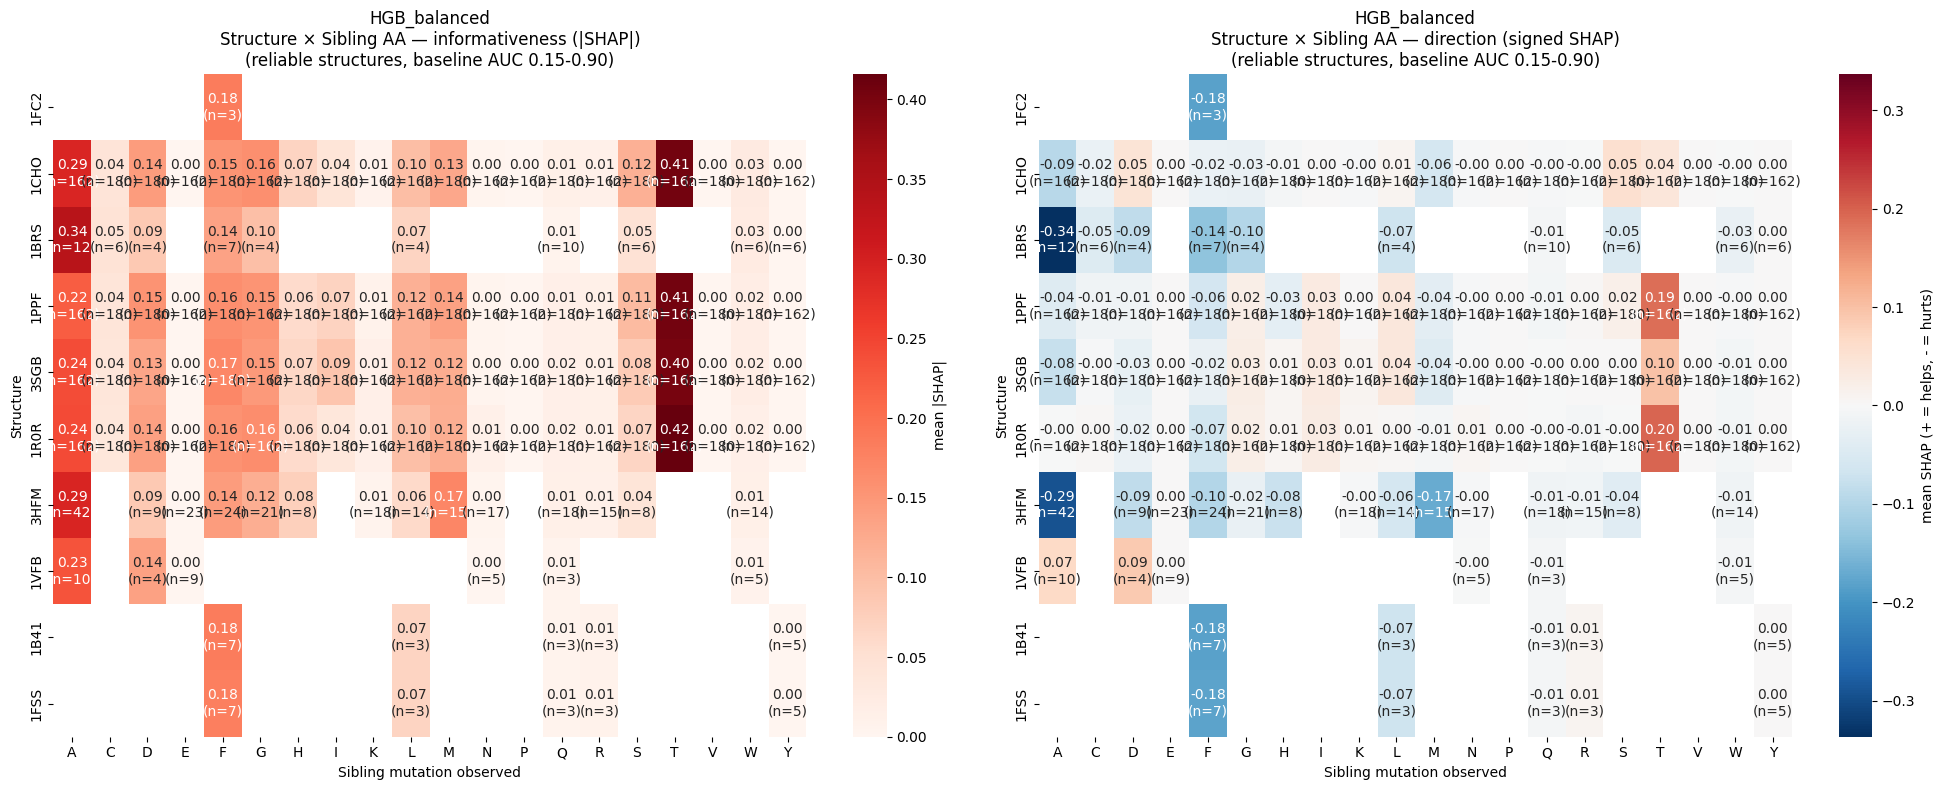

In [23]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Filter to reliable mid-range structures ───────────────────────────────────
reliable_mid = dff['pdb_id'].unique()  # or use a predefined list of reliable structures

for model_name in ['HGB_balanced']:

    # ── Fit & SHAP ────────────────────────────────────────────────────────────
    clf = models_trees[model_name]
    clf.fit(X_trees_2, yy_f2)

    explainer   = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_trees_2)

    if isinstance(shap_values, list):
        shap_class1 = shap_values[1]
    elif shap_values.ndim == 3:
        shap_class1 = shap_values[:, :, 1]
    else:
        shap_class1 = shap_values

    shap_df = pd.DataFrame(shap_class1, columns=X_trees_2.columns, index=X_trees_2.index)

    sibling_aas = [c.replace('sibling_ddg_', '') for c in X_trees_2.columns
                   if c.startswith('sibling_ddg_')]

    # ── Build structure × sibling_AA matrix ──────────────────────────────────
    rows = []
    for structure in g_f2.unique():
        if structure not in reliable_mid:
            continue
        struct_mask = g_f2 == structure
        for sib_aa in sibling_aas:
            sib_col = f'sibling_ddg_{sib_aa}'
            mask = struct_mask & X_trees_2[sib_col].notna()
            if mask.sum() < 3:
                continue
            rows.append({
                'structure':     structure,
                'sibling':       sib_aa,
                'mean_abs_shap': shap_df.loc[mask, sib_col].abs().mean(),
                'mean_shap':     shap_df.loc[mask, sib_col].mean(),
                'n':             mask.sum(),
            })

    struct_sib_df_filtered = pd.DataFrame(rows)

    if struct_sib_df_filtered.empty:
        print(f"{model_name}: no data after filtering")
        continue

    # ── Pivot tables ──────────────────────────────────────────────────────────
    pivot_abs = struct_sib_df_filtered.pivot_table(
        index='structure', columns='sibling', values='mean_abs_shap'
    )
    pivot_signed = struct_sib_df_filtered.pivot_table(
        index='structure', columns='sibling', values='mean_shap'
    )
    pivot_n = struct_sib_df_filtered.pivot_table(
        index='structure', columns='sibling', values='n', aggfunc='sum'
    )

    # Sort by total informativeness
    pivot_abs    = pivot_abs.loc[pivot_abs.mean(axis=1).sort_values(ascending=False).index]
    pivot_signed = pivot_signed.loc[pivot_abs.index]

    # ── Annotation helper ─────────────────────────────────────────────────────
    def make_annot(pivot_val, pivot_n):
        annot = pivot_val.copy().astype(object)
        for r in pivot_val.index:
            for c in pivot_val.columns:
                try:
                    v = pivot_val.loc[r, c]
                    n = pivot_n.loc[r, c] if (r in pivot_n.index and
                                               c in pivot_n.columns) else 0
                    annot.loc[r, c] = f"{v:.2f}\n(n={int(n)})" if not np.isnan(v) else ""
                except:
                    annot.loc[r, c] = ""
        return annot

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    sns.heatmap(pivot_abs,
                annot=make_annot(pivot_abs, pivot_n),
                fmt="", cmap='Reds', ax=axes[0],
                cbar_kws={'label': 'mean |SHAP|'})
    axes[0].set_title(f'{model_name}\nStructure × Sibling AA — informativeness (|SHAP|)\n'
                      f'(reliable structures, baseline AUC 0.15-0.90)')
    axes[0].set_xlabel('Sibling mutation observed')
    axes[0].set_ylabel('Structure')

    vmax = np.nanmax(np.abs(pivot_signed.values))
    sns.heatmap(pivot_signed,
                annot=make_annot(pivot_signed, pivot_n),
                fmt="", cmap='RdBu_r', center=0,
                vmin=-vmax, vmax=vmax, ax=axes[1],
                cbar_kws={'label': 'mean SHAP (+ = helps, - = hurts)'})
    axes[1].set_title(f'{model_name}\nStructure × Sibling AA — direction (signed SHAP)\n'
                      f'(reliable structures, baseline AUC 0.15-0.90)')
    axes[1].set_xlabel('Sibling mutation observed')
    axes[1].set_ylabel('Structure')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'shap_structure_sibling.png')
    plt.show()

### Baseline - only Final ddg of foldx

In [ ]:
selected_cols = [col for col in XX.columns if  'foldx' in col ]

In [ ]:
from sklearn.metrics import roc_auc_score
# ── Train on >=2 mutations, reliable structures only ─────────────────────────
pos_filter_2    = filter_multi_mutation_positions(g, dff['resnum'], min_mutations=2)
reliable_mask_2 = pos_filter_2 #& g.isin(structs_both_class)

XX_f2  = XX[reliable_mask_2]
dff_f2 = dff[reliable_mask_2]
g_f2   = g[reliable_mask_2]
yy_f2  = yy[reliable_mask_2]

print(f"Training set: {len(XX_f2)} mutations, {g_f2.nunique()} structures")
print(f"Class balance: {yy_f2.mean():.2f}")

X_trees_2 = add_sibling_features(XX_f2[selected_cols], dff_f2, g_f2,
                                   dff_f2['resnum'], dff_f2['mut_to'],
                                   ddg_col='DDG', mode='trees')
X_lr_2    = add_sibling_features(XX_f2[selected_cols], dff_f2, g_f2,
                                   dff_f2['resnum'], dff_f2['mut_to'],
                                   ddg_col='DDG', mode='lr')

# ── Evaluate only on >=3 positions ───────────────────────────────────────────
pos_filter_3 = filter_multi_mutation_positions(g_f2, dff_f2['resnum'], min_mutations=2)
eval_mask    = pd.Series(pos_filter_3.values, index=X_trees_2.index)

print(f"Evaluation set (>=3 muts/pos): {eval_mask.sum()} mutations")

raw_no_sib , df_imp_no_sib   = run_cv_kfold(X_trees_2[[c for c in X_trees_2.columns
                             if 'sibling_ddg' not in c]],
                             yy_f2, models_trees, groups=g_f2,
                             n_splits=4, raw=True , feature_importance=True,use_permutation=True)

raw_with_sib , df_imp_sib = run_cv_kfold(X_trees_2, yy_f2, models_trees,
                             groups=g_f2, n_splits=4, raw=True , feature_importance=True,use_permutation=True)

raw_no_sib_eval   = raw_no_sib[raw_no_sib['idx'].isin(X_trees_2[eval_mask].index)]
raw_with_sib_eval = raw_with_sib[raw_with_sib['idx'].isin(X_trees_2[eval_mask].index)]

raw_no_sib_eval['logloss'] = logloss(raw_no_sib_eval)
raw_with_sib_eval['logloss'] = logloss(raw_with_sib_eval)


INFO | Position filter (>=2 mutations): 82/82 positions kept, 895/1263 mutations kept
INFO | Sibling features (mode='trees'): 20 AA columns | coverage=78.8% | 895/895 mutations have ≥1 sibling
INFO | Sibling features (mode='lr'): 20 AA columns | coverage=100.0% | 895/895 mutations have ≥1 sibling
INFO | Position filter (>=2 mutations): 82/82 positions kept, 895/895 mutations kept


Training set: 895 mutations, 10 structures
Class balance: 0.21
Evaluation set (>=3 muts/pos): 895 mutations
Test set : Fold  0, model RF_balanced: AUC=0.643, BalAcc=0.678, LogLoss=0.635
Train set : Fold  0, model RF_balanced: AUC=0.692, BalAcc=0.636, LogLoss=0.629
Test set : Fold  0, model HGB_balanced: AUC=0.655, BalAcc=0.678, LogLoss=0.651
Train set : Fold  0, model HGB_balanced: AUC=0.705, BalAcc=0.650, LogLoss=0.629
Test set : Fold  1, model RF_balanced: AUC=0.673, BalAcc=0.663, LogLoss=0.592
Train set : Fold  1, model RF_balanced: AUC=0.694, BalAcc=0.637, LogLoss=0.629
Test set : Fold  1, model HGB_balanced: AUC=0.670, BalAcc=0.688, LogLoss=0.609
Train set : Fold  1, model HGB_balanced: AUC=0.687, BalAcc=0.648, LogLoss=0.634
Test set : Fold  2, model RF_balanced: AUC=0.621, BalAcc=0.594, LogLoss=0.659
Train set : Fold  2, model RF_balanced: AUC=0.706, BalAcc=0.650, LogLoss=0.622
Test set : Fold  2, model HGB_balanced: AUC=0.644, BalAcc=0.631, LogLoss=0.645
Train set : Fold  2, mod

In [ ]:
print("\nNo siblings (evaluated on >=3 positions, reliable structures):")
for name, grp in raw_no_sib_eval.groupby('model'):
    print(f"  {name}: AUC={roc_auc_score(grp['y_true'], grp['y_proba']):.3f}")
    print(f"  {name}: Log Loss={grp['logloss'].mean():.3f}")

print("\nWith siblings (evaluated on >=3 positions, reliable structures):")
for name, grp in raw_with_sib_eval.groupby('model'):
    print(f"  {name}: AUC={roc_auc_score(grp['y_true'], grp['y_proba']):.3f}")
    print(f"  {name}: Log Loss={grp['logloss'].mean():.3f}")


No siblings (evaluated on >=3 positions, reliable structures):
  HGB_balanced: AUC=0.634
  HGB_balanced: Log Loss=0.647
  RF_balanced: AUC=0.620
  RF_balanced: Log Loss=0.643

With siblings (evaluated on >=3 positions, reliable structures):
  HGB_balanced: AUC=0.847
  HGB_balanced: Log Loss=0.461
  RF_balanced: AUC=0.844
  RF_balanced: Log Loss=0.475
